<a href="https://colab.research.google.com/github/antaleksandrgit-oss/spaceship-titanic/blob/main/notebooks/spaceship_titanic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [4]:
!pip install kagglehub -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

sns.set_style("whitegrid")
%matplotlib inline

print("Все библиотеки загружены!")

Все библиотеки загружены!


In [7]:
import zipfile
import pandas as pd
from google.colab import files

# 1. Загружаем ZIP-архив с вашего компьютера
print("Пожалуйста, выберите файл 'spaceship-titanic.zip' на вашем компьютере.")
uploaded = files.upload()

# 2. Находим имя загруженного файла (оно может быть 'spaceship-titanic.zip')
#    и распаковываем его.
for filename in uploaded.keys():
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall('/content/data')
    print(f"Файл {filename} успешно распакован в папку /content/data")

# 3. Загружаем данные в переменные pandas
train_df = pd.read_csv('/content/data/train.csv')
test_df = pd.read_csv('/content/data/test.csv')
sample_sub = pd.read_csv('/content/data/sample_submission.csv')

# 4. Проверяем, что всё загрузилось правильно
print(f"Размер обучающей выборки (train): {train_df.shape}")
print(f"Размер тестовой выборки (test): {test_df.shape}")
print(train_df.head())

Пожалуйста, выберите файл 'spaceship-titanic.zip' на вашем компьютере.


Saving spaceship-titanic.zip to spaceship-titanic (1).zip
Файл spaceship-titanic (1).zip успешно распакован в папку /content/data
Размер обучающей выборки (train): (8693, 14)
Размер тестовой выборки (test): (4277, 13)
  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  33

In [8]:
train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


Видим 14 столбцов. Есть пропуски в `Age`, `Cabin`, `HomePlanet` и других. Обратим внимание на `CryoSleep` - возможно, он связан с нулевыми тратами.

In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


В `Age` 179 пропусков, в `Cabin` 199, в `HomePlanet` 201. Это нужно будет обработать. Также `Cabin` - сложный признак, его можно разбить на части.

In [10]:
# Размеры и типы
print(train_df.shape)
print(train_df.dtypes)

(8693, 14)
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object


In [11]:
# Статистика по числовым столбцам
train_df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


Минимальные значения в `RoomService`, `FoodCourt` и т.д. равны 0, а максимальные - очень большие. Возможно, есть выбросы. Пассажиры с `CryoSleep = True` могли не пользоваться услугами.

In [13]:
# Распределение целевой переменной
train_df['Transported'].value_counts(normalize=True)

,proportion
Transported,
True,0.503624
False,0.496376


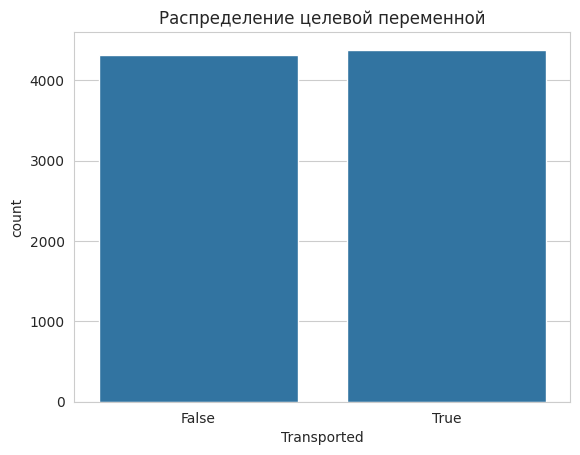

In [14]:
sns.countplot(data=train_df, x='Transported')
plt.title('Распределение целевой переменной')
plt.show()

Классы сбалансированы (почти 50/50). Это упрощает задачу: accuracy будет объективной метрикой, а базовое предсказание — 0.5.

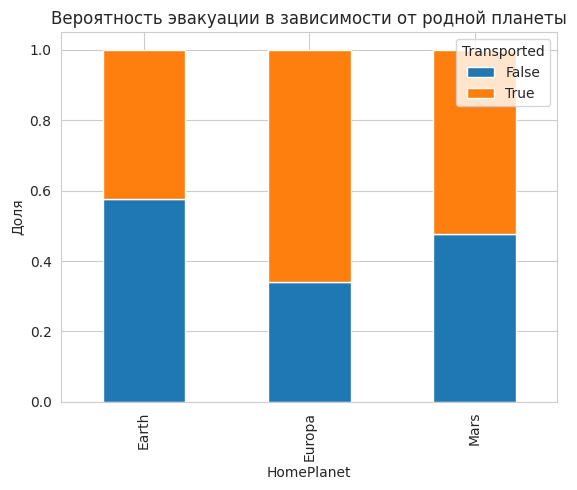

In [15]:
# Зависимость HomePlanet от Transported
pd.crosstab(train_df['HomePlanet'], train_df['Transported'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Вероятность эвакуации в зависимости от родной планеты')
plt.ylabel('Доля')
plt.show()

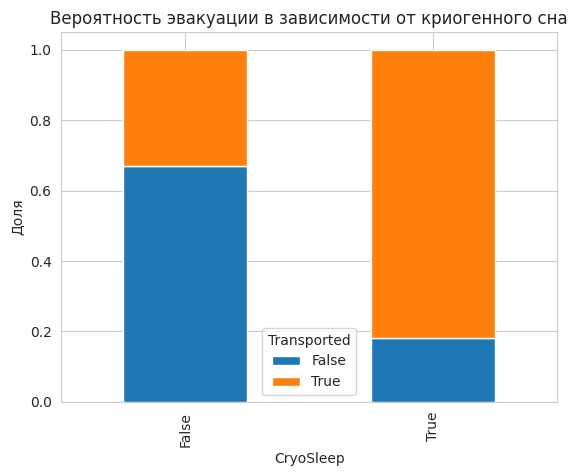

In [16]:
# Зависимость CryoSleep от Transported
pd.crosstab(train_df['CryoSleep'], train_df['Transported'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Вероятность эвакуации в зависимости от криогенного сна')
plt.ylabel('Доля')
plt.show()

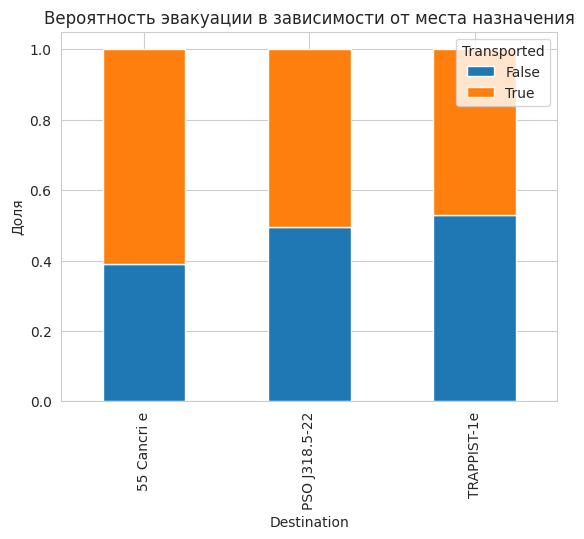

In [17]:
# Зависимость Destination от Transported
pd.crosstab(train_df['Destination'], train_df['Transported'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Вероятность эвакуации в зависимости от места назначения')
plt.ylabel('Доля')
plt.show()

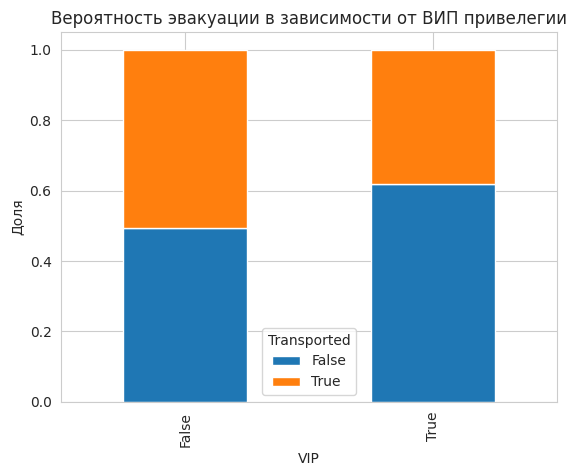

In [18]:
# Зависимость VIP от Transported
pd.crosstab(train_df['VIP'], train_df['Transported'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Вероятность эвакуации в зависимости от ВИП привелегии')
plt.ylabel('Доля')
plt.show()

Наглядно видим, что пассажиры с `CryoSleep = False` спасаются чаще

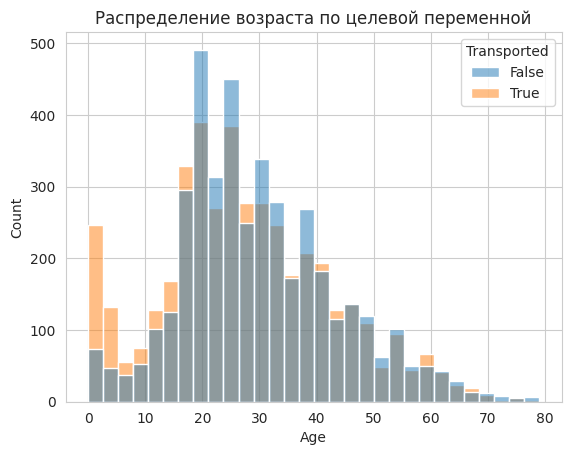

In [19]:
# Гистограмма возраста с разделением по Transported
sns.histplot(data=train_df, x='Age', hue='Transported', bins=30, alpha=0.5)
plt.title('Распределение возраста по целевой переменной')
plt.show()

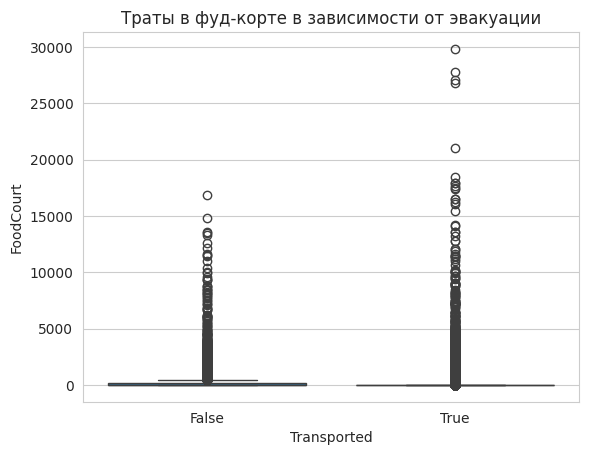

In [20]:
# Boxplot для трат (например, FoodCourt)
sns.boxplot(data=train_df, x='Transported', y='FoodCourt')
plt.title('Траты в фуд-корте в зависимости от эвакуации')
plt.show()

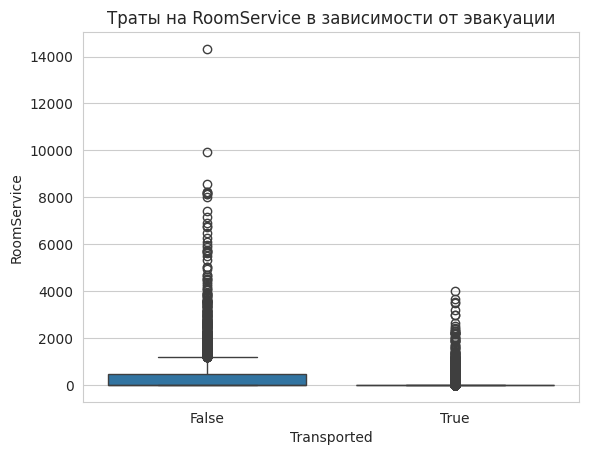

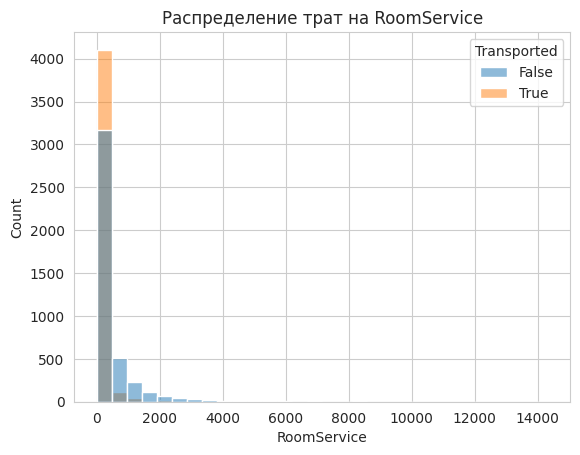

In [26]:
sns.boxplot(data=train_df, x='Transported', y='RoomService')
plt.title('Траты на RoomService в зависимости от эвакуации')
plt.show()

sns.histplot(data=train_df, x='RoomService', hue='Transported', bins=30, alpha=0.5)
plt.title('Распределение трат на RoomService')
plt.show()

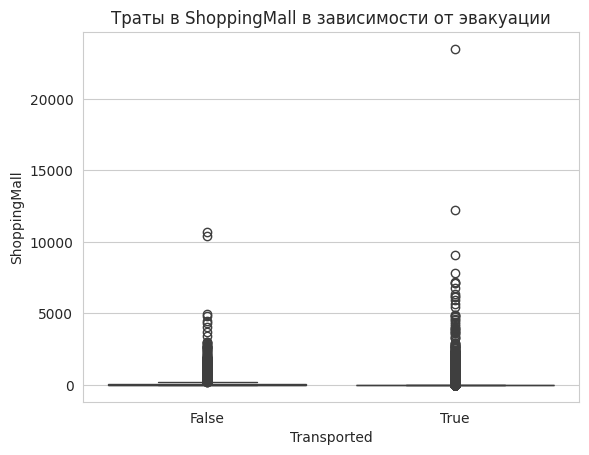

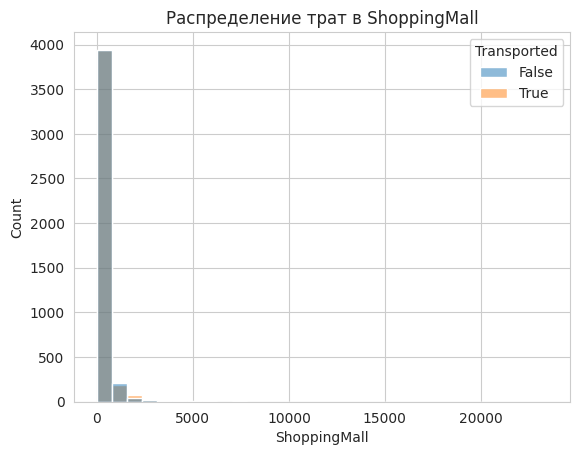

In [27]:
sns.boxplot(data=train_df, x='Transported', y='ShoppingMall')
plt.title('Траты в ShoppingMall в зависимости от эвакуации')
plt.show()

sns.histplot(data=train_df, x='ShoppingMall', hue='Transported', bins=30, alpha=0.5)
plt.title('Распределение трат в ShoppingMall')
plt.show()

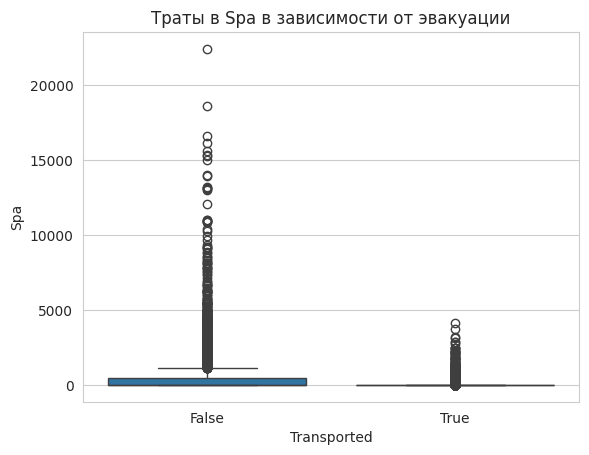

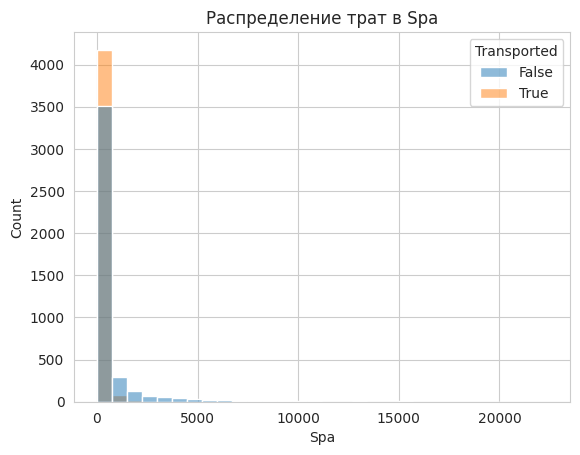

In [28]:
sns.boxplot(data=train_df, x='Transported', y='Spa')
plt.title('Траты в Spa в зависимости от эвакуации')
plt.show()

sns.histplot(data=train_df, x='Spa', hue='Transported', bins=30, alpha=0.5)
plt.title('Распределение трат в Spa')
plt.show()

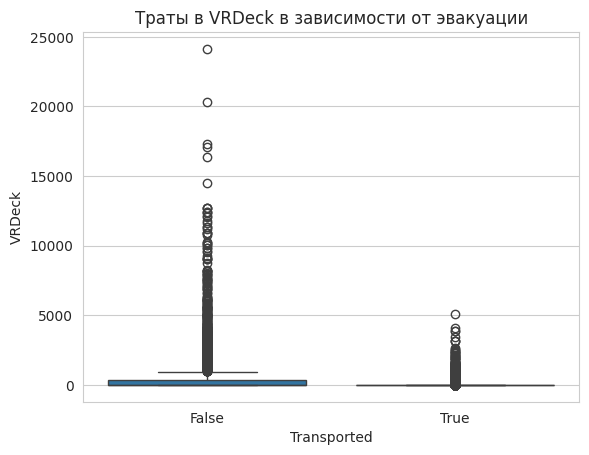

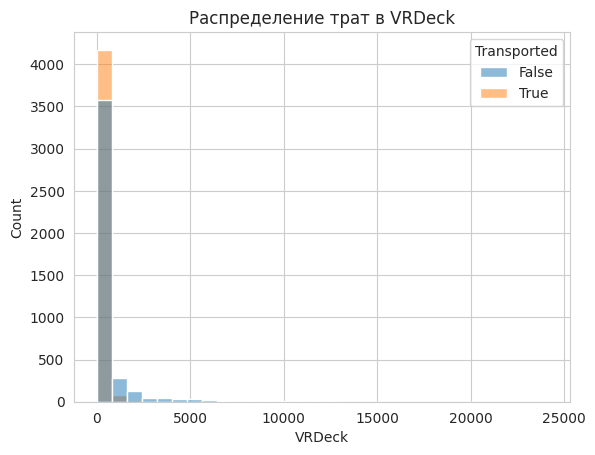

In [29]:
sns.boxplot(data=train_df, x='Transported', y='VRDeck')
plt.title('Траты в VRDeck в зависимости от эвакуации')
plt.show()

sns.histplot(data=train_df, x='VRDeck', hue='Transported', bins=30, alpha=0.5)
plt.title('Распределение трат в VRDeck')
plt.show()

Выводы по числовым признакам (траты):

По всем категориям `(RoomService, FoodCourt, ShoppingMall, Spa, VRDeck) `наблюдается одна и та же картина: большинство пассажиров тратят 0 или очень мало. Распределение сильно скошено вправо.

Интересно, что у пассажиров, которые не были эвакуированы `(Transported = False)`, чуть выше доля нулевых трат. То есть те, кто хоть что-то потратил, имеют немного больше шансов на спасение.

Выбросы (очень высокие траты) встречаются редко и примерно одинаково в обеих группах.

In [30]:
# Сначала посмотрим на уникальные значения
train_df['Cabin'].unique()[:20]

array(['B/0/P', 'F/0/S', 'A/0/S', 'F/1/S', 'F/0/P', 'F/2/S', 'G/0/S',
       'F/3/S', 'B/1/P', 'F/1/P', 'G/1/S', 'F/2/P', nan, 'F/3/P', 'F/4/P',
       'F/5/P', 'G/0/P', 'F/6/P', 'E/0/S', 'D/0/P'], dtype=object)

In [31]:
# Извлекаем компоненты (если значение не пропущено)
def extract_cabin_features(df):
    df['Deck'] = df['Cabin'].str[0]  # первая буква
    df['CabinNum'] = df['Cabin'].str.split('/').str[1]  # номер каюты (как строка)
    df['Side'] = df['Cabin'].str.split('/').str[2]  # P или S
    return df

train_df = extract_cabin_features(train_df)
test_df = extract_cabin_features(test_df)

# Проверяем
train_df[['Cabin', 'Deck', 'CabinNum', 'Side']].head(10)

,Cabin,Deck,CabinNum,Side
0,B/0/P,B,0,P
1,F/0/S,F,0,S
2,A/0/S,A,0,S
3,A/0/S,A,0,S
4,F/1/S,F,1,S
5,F/0/P,F,0,P
6,F/2/S,F,2,S
7,G/0/S,G,0,S
8,F/3/S,F,3,S
9,B/1/P,B,1,P


Признак `Cabin` разбит на три: Deck, CabinNum, Side. Теперь мы можем проверить, влияет ли палуба или сторона корабля на вероятность эвакуации.

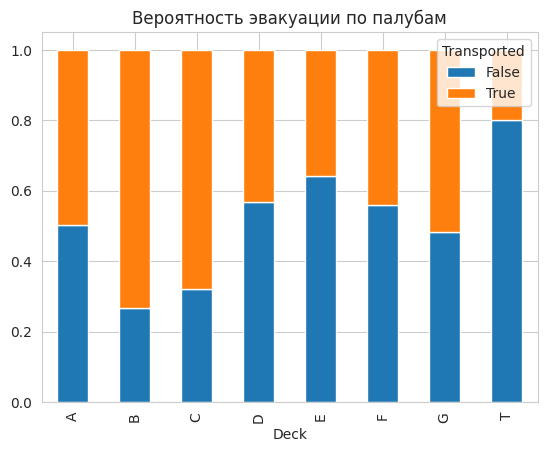

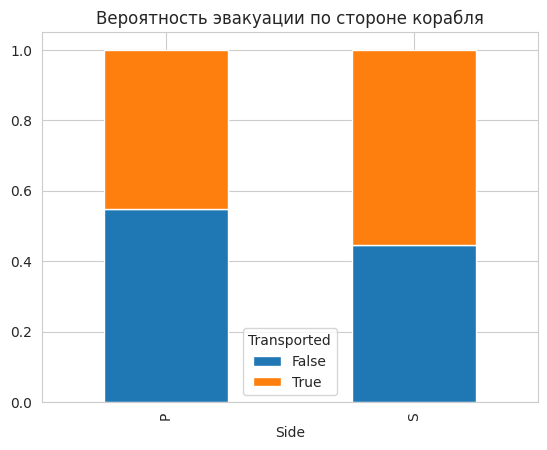

In [32]:
# Влияние палубы на эвакуацию
pd.crosstab(train_df['Deck'], train_df['Transported'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Вероятность эвакуации по палубам')
plt.show()
# Влияние стороны корабля
pd.crosstab(train_df['Side'], train_df['Transported'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Вероятность эвакуации по стороне корабля')
plt.show()

По палубам (Deck_clean): Палубы B, C, D показывают наибольшую долю эвакуированных (более 50%). Самая низкая вероятность спасения — на палубах G и T (менее 30%). Палуба A — примерно равные шансы. Это может быть связано с расположением спасательных шлюпок или классом обслуживания.

По стороне корабля (Side_clean): Пассажиры на правом борту S (Starboard) эвакуируются значительно чаще, чем на левом P (Port). Разница составляет около 10–15 процентных пунктов. Это сильный признак для модели.

Пропуски (Unknown) встречаются в небольшом проценте случаев, их нужно будет заполнить или оставить как отдельную категорию.

In [34]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
train_df['TotalSpent'] = train_df[spend_cols].sum(axis=1)
test_df['TotalSpent'] = test_df[spend_cols].sum(axis=1)

train_df['UsedAnyService'] = (train_df['TotalSpent'] > 0).astype(int)
test_df['UsedAnyService'] = (test_df['TotalSpent'] > 0).astype(int)Ы

In [35]:
train_df['UsedAnyService'] = (train_df['TotalSpent'] > 0).astype(int)
test_df['UsedAnyService'] = (test_df['TotalSpent'] > 0).astype(int)

`TotalSpent` объединяет траты, усиливая сигнал.

`UsedAnyService` выделяет факт пользования услугами — из EDA это положительно влияет на эвакуацию.

In [36]:
# Проверяем текущие пропуски
print(train_df.isnull().sum())

PassengerId         0
HomePlanet        201
CryoSleep         217
Cabin             199
Destination       182
Age               179
VIP               203
RoomService       181
FoodCourt         183
ShoppingMall      208
Spa               183
VRDeck            188
Name              200
Transported         0
Deck              199
CabinNum          199
Side              199
TotalSpent          0
UsedAnyService      0
dtype: int64


In [38]:
# Заполняем Age медианой
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())

# Заполняем HomePlanet самой частой категорией
train_df['HomePlanet'] = train_df['HomePlanet'].fillna(train_df['HomePlanet'].mode()[0])

# Для CryoSleep и VIP: пропуски, скорее всего, означают False
train_df['CryoSleep'] = train_df['CryoSleep'].fillna(False)
train_df['VIP'] = train_df['VIP'].fillna(False)

# Для признаков трат (если есть пропуски) — заполним нулём
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in spend_cols:
    train_df[col] = train_df[col].fillna(0)

# Для Deck_clean и Side_clean (создаём, если ещё нет)
if 'Deck_clean' not in train_df.columns:
    train_df['Deck_clean'] = train_df['Deck'].fillna('Unknown')
if 'Side_clean' not in train_df.columns:
    train_df['Side_clean'] = train_df['Side'].fillna('Unknown')

# Пересоздаём TotalSpent и UsedAnyService
train_df['TotalSpent'] = train_df[spend_cols].sum(axis=1)
train_df['UsedAnyService'] = (train_df['TotalSpent'] > 0).astype(int)

# Проверяем, что пропусков больше нет (кроме тех, что мы не трогаем)
print("Пропуски после обработки:")
print(train_df[['Age', 'HomePlanet', 'CryoSleep', 'VIP', 'Deck_clean', 'Side_clean', 'TotalSpent']].isnull().sum())

Пропуски после обработки:
Age           0
HomePlanet    0
CryoSleep     0
VIP           0
Deck_clean    0
Side_clean    0
TotalSpent    0
dtype: int64


In [39]:
# Выберем признаки для модели
features = ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'TotalSpent', 'UsedAnyService', 'Deck_clean', 'Side_clean']
X = train_df[features]
y = train_df['Transported']

# Кодируем категориальные
X_encoded = pd.get_dummies(X, columns=['HomePlanet', 'Destination', 'Deck_clean', 'Side_clean'], drop_first=True)
# CryoSleep и VIP уже числовые (bool), их не надо кодировать

In [40]:
X_train, X_val, y_train, y_val = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Валидационная выборка: {X_val.shape}")

Обучающая выборка: (6954, 19)
Валидационная выборка: (1739, 19)


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Создаём и обучаем модель
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Предсказываем на валидации
y_pred = rf.predict(X_val)

# Оцениваем качество
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy на валидации: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Accuracy на валидации: 0.7073

Classification Report:
              precision    recall  f1-score   support

       False       0.69      0.74      0.71       861
        True       0.72      0.68      0.70       878

    accuracy                           0.71      1739
   macro avg       0.71      0.71      0.71      1739
weighted avg       0.71      0.71      0.71      1739



Вывод по модели:

Первая модель RandomForest показала accuracy ≈ 0.71.

Это значительно лучше случайного угадывания (0.5).

Precision и recall для классов примерно сбалансированы.

Дальнейшие улучшения: подбор гиперпараметров, попробовать XGBoost, добавить больше признаков (например, размер семьи).